In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [3]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [7]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    seed=42,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=42
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [8]:
loglike_obj.signal

array([[-1.71638694e-21,  8.07616732e-21, -1.98450906e-20, ...,
        -1.46711625e-20,  1.41503064e-20, -3.11805805e-21],
       [-1.26891406e-20,  7.31258751e-21, -1.10576472e-20, ...,
         1.49434225e-20,  7.24023829e-22,  1.15504059e-20],
       [ 1.00963772e-20, -2.85407943e-21, -7.91870500e-21, ...,
        -1.41285941e-20,  1.28345637e-20, -1.50946246e-20]])

In [9]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 28.41
Time-maximized Log-likelihood: 24.7549
24.75490205176527
CPU times: user 401 ms, sys: 24.8 ms, total: 426 ms
Wall time: 514 ms


In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=6.875, rho=2.622
  Mode 1: <hf|hf>_timemax=42.86, rho=6.547
  Mode 2: <hf|hf>_timemax=188, rho=13.71
  Mode 3: <hf|hf>_timemax=182.7, rho=13.52
  Mode 4: <hf|hf>_timemax=92.65, rho=9.626
  Mode 5: <hf|hf>_timemax=32.88, rho=5.734
  Mode 6: <hf|hf>_timemax=9.439, rho=3.072
rho_m: [ 2.62194231  6.54677249 13.71105146 13.51510149  9.6256335   5.73420621
  3.07223736]
Dominant mode index: 2, rho: 13.71
beta=0.01208, rho_dom_M=13.71, rho_tot=24.93
X_scalar (time-maximized): 5.04
Time-maximized Log-likelihood: 0.65031
0.6503100724301882


In [11]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [12]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [13]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 28.41
Time-maximized Log-likelihood: 24.7549
24.75490205176527


In [14]:
# # Sweep over logm2
# param_idx = 1  # logm2
# # param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

# param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

# f_stats_tm   = np.zeros(len(param_range))
# # f_stats_pm   = np.zeros(len(param_range))
# # f_stats_pure = np.zeros(len(param_range))
# # f_stats_tmX = np.zeros(len(param_range))
# # X_pure = np.zeros(len(param_range))
# X_tm = np.zeros(len(param_range))
# X_tpm = np.zeros(len(param_range))
# X_sc = np.zeros(len(param_range))


# for i, val in enumerate(param_range):

#     p = param_true.copy()
#     p[param_idx] = val
#     # f_stats_tm[i]   = logden_tm(p)
#     # f_stats_pm[i]   = logden_pm(p)
#     # f_stats_pure[i] = logden_pure(p)
#     # f_stats_tmX[i] = logden_tmX(p)

#     # X only (no chi_sq)
#     logm1, logm2, a_i, p0_i, e0_i = p
#     h = gwf.xp.array(waveform_response(
#         10**logm1, 10**logm2, a_i, p0_i, e0_i,
#         xI0, dist, qS, phiS, qK, phiK,
#         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
#     ))
#     h_fft_r = gwf.freq_wave(h)
#     rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
#     # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
#     # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=False)) / rho_h
#     # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=True)) / rho_h
#     X_sc[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))

In [15]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [16]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [17]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
# f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# f_stats_tmX = np.zeros(len(param_range))
# X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))
X_tpm = np.zeros(len(param_range))
Sf = np.zeros(len(param_range))
# Ssix = np.zeros(len(param_range))
Sfour = np.zeros(len(param_range))
# Ssixteen = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    # f_stats_tm[i]   = logden_tm(p)
    # f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    # f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=4))
    # Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    theta_template = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]

    # same mode selection the loglike uses
    selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels
    hm_arr = loglike_obj._generate_selected_waveforms(theta_template, selected)  # (N_groups, n_chan, N)

    Sf[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=6))   # beta auto-computed
    # Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))

In [18]:
Sf

array([ 4.45238159,  4.57047898,  4.38551861,  4.61572692,  4.71546696,
        4.71835962,  5.08257707,  5.30530881,  5.19402885,  5.28895589,
        5.14719748,  5.29348723,  5.18950012,  5.15392435,  5.2323595 ,
        5.03110031,  5.19414093,  5.10394942,  5.00228748,  5.18650557,
        5.02511316,  5.16594421,  5.46126896,  5.30454436,  5.69777578,
        5.5084738 ,  5.5245327 ,  5.76139284,  5.46222999,  5.74633055,
        5.9150701 ,  6.15580648,  6.67407304,  6.89163697,  7.35934912,
        7.41680902,  7.48719616,  7.97344649,  7.79379988,  8.2942198 ,
        8.58331493,  8.79419107,  9.75681838, 10.50743399, 10.84033519,
       11.03687   , 10.99975697, 11.13725732, 11.11229017, 10.75373011,
       11.5757935 , 10.12857118, 10.37392342, 10.55513935, 10.77056794,
       11.01365923, 10.27870697,  9.91618649,  9.32659639,  8.9848501 ,
        8.78400811,  8.76873834,  7.88344751,  7.49342777,  6.99617289,
        7.07266273,  6.7198631 ,  6.68662719,  6.79565365,  6.22

In [19]:
import matplotlib.pyplot as plt

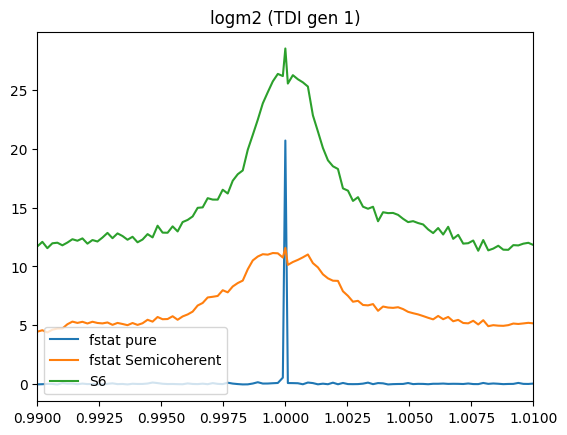

In [20]:
# plt.plot(param_range, f_stats_tm,   label='fstat timemax only')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')
# plt.plot(param_range, X_tpm, label='X timemax +phasemax')
plt.plot(param_range, Sf, label='fstat Semicoherent')
# plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Sfour, label='S6')
# plt.plot(param_range, Ssixteen, labe6l='S16')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Sweep over logm2
Sfour = np.zeros(len(param_range))
Ssix = np.zeros(len(param_range))
Stwelve = np.zeros(len(param_range))
Ssixteen = np.zeros(len(param_range))


Sf_four = np.zeros(len(param_range))
Sf_six = np.zeros(len(param_range))
Sf_twelve = np.zeros(len(param_range))
Sf_sixteen = np.zeros(len(param_range))

for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=4))
    Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))

    theta_template = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]

    # same mode selection the loglike uses
    selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels
    hm_arr = loglike_obj._generate_selected_waveforms(theta_template, selected)  # (N_groups, n_chan, N)

    Sf_four[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=4))  
    Sf_six[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=6))  
    Sf_twelve[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=12))  
    Sf_sixteen[i] = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=16))  

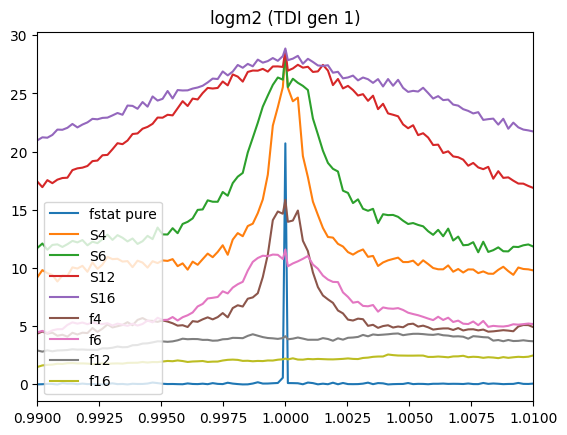

In [22]:
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, Sfour, label='S4')
plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Stwelve, label='S12')
plt.plot(param_range, Ssixteen, label='S16')

plt.plot(param_range, Sf_four, label='f4')
plt.plot(param_range, Sf_six, label='f6')
plt.plot(param_range, Sf_twelve, label='f12')
plt.plot(param_range, Sf_sixteen, label='f16')


plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

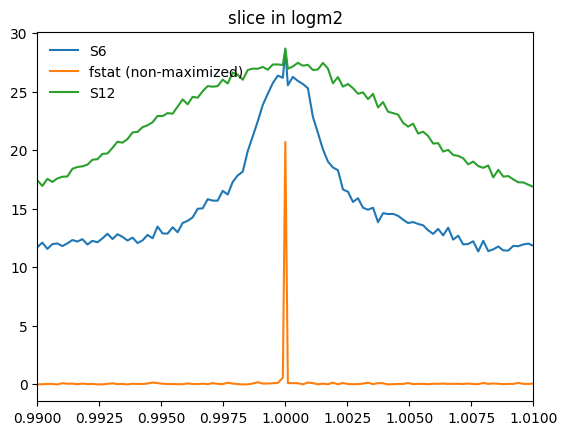

In [23]:
plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, f_stats_pure, label='fstat (non-maximized)')

plt.plot(param_range, Stwelve, label='S12')

plt.xlim(0.99, 1.01)
plt.title('slice in logm2')
plt.legend(loc='upper left', frameon=False)
plt.show()

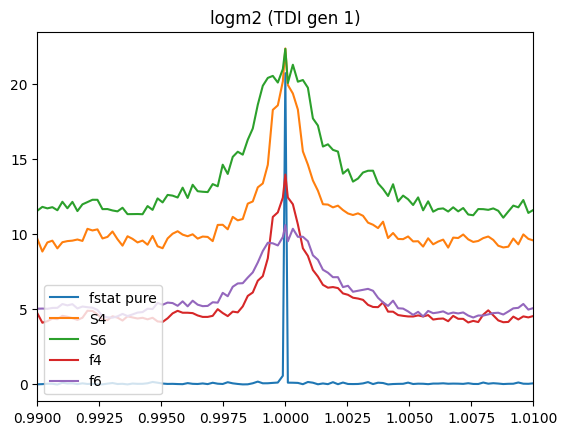

In [23]:
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, Sfour, label='S4')
plt.plot(param_range, Ssix, label='S6')
# plt.plot(param_range, Stwelve, label='S12')
# plt.plot(param_range, Ssixteen, label='S16')

plt.plot(param_range, Sf_four, label='f4')
plt.plot(param_range, Sf_six, label='f6')
# plt.plot(param_range, Sf_twelve, label='f12')
# plt.plot(param_range, Sf_sixteen, label='f16')


plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

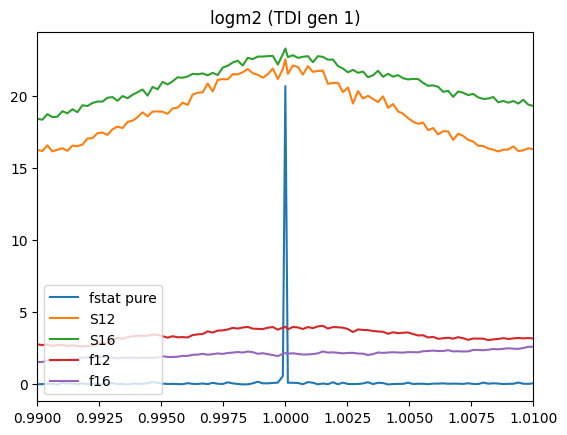

In [24]:
plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, Sfour, label='S4')
# plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Stwelve, label='S12')
plt.plot(param_range, Ssixteen, label='S16')

# plt.plot(param_range, Sf_four, label='f4')
# plt.plot(param_range, Sf_six, label='f6')
plt.plot(param_range, Sf_twelve, label='f12')
plt.plot(param_range, Sf_sixteen, label='f16')


plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

In [25]:
def chi2_pure(params):
    """Coherent chi^2 + suppression factor, matching loglike_pure_noise.
    Returns dict: chi_sq, suppression, beta, X_scalar (so f_pure = X_scalar*suppression)."""
    logm1, logm2, a_i, p0_i, e0_i = params
    theta = [10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]

    gwfp = loglike_p.gwf
    selected = loglike_p.mode_select if loglike_p.mode_select else loglike_p.selected_labels
    wf_comb  = loglike_p._generate_selected_waveforms(theta, selected)

    h_temp = gwfp.xp.array(loglike_p.waveform_response(*theta, T=loglike_p.T, dt=loglike_p.dt))
    h_fft  = gwfp.freq_wave(h_temp)
    mode_ffts = [gwfp.freq_wave(wf_comb[i]) for i in range(wf_comb.shape[0])]

    rho_tot = float(gwfp.xp.sqrt(gwfp.inner(h_fft, h_fft)))
    rho_m = gwfp.xp.array([float(gwfp.xp.sqrt(gwfp.inner(hf, hf))) for hf in mode_ffts])

    beta = float(gwfp.calc_beta(rho_m.max(), rho_tot))

    X_scalar = float(gwfp.inner(loglike_p.signal_fft, h_fft, return_complex=False)) / rho_tot
    X_modes = gwfp.xp.array([
        float(gwfp.inner(loglike_p.signal_fft, hf, return_complex=False)) / float(rho_m[idx])
        for idx, hf in enumerate(mode_ffts)
    ])

    chi_sq = float(gwfp.chi_sq(X_modes, rho_m))
    suppression = float(gwfp.xp.exp(-0.5 * beta * chi_sq))
    return {'chi_sq': chi_sq, 'suppression': suppression, 'beta': beta, 'X_scalar': X_scalar}

In [26]:
chi_sq_pure   = np.zeros(len(param_range))
supp_pure     = np.zeros(len(param_range))

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    out = chi2_pure(p)
    chi_sq_pure[i] = out['chi_sq']
    supp_pure[i]   = out['suppression']

In [27]:
# Check the exponential suppression factor of the semi-coherent f-stat
# Sf = S * exp(-0.5 * beta * chi_sq);  chi2_semi exposes chi_sq + suppression.
chi_sq_sc   = np.zeros(len(param_range))
suppression = np.zeros(len(param_range))
beta_sc     = np.zeros(len(param_range))

selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    logm1, logm2, a_i, p0_i, e0_i = p

    theta = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]
    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)

    out = gwf.chi2_semi(loglike_obj.signal, h, hm_arr, N_seg=4)
    chi_sq_sc[i]   = out['chi_sq']
    suppression[i] = out['suppression']
    beta_sc[i]     = out['beta']

In [28]:
chi_sq_sc

array([116.6072991 , 125.1149509 , 132.01879644, 127.57934097,
       120.22323041, 119.21827976, 123.14979705, 126.87851389,
       132.78638723, 125.77422103, 122.71460549, 121.58332258,
       130.52747162, 133.28705815, 136.62607919, 133.32786834,
       128.13942883, 128.24412879, 128.4698713 , 128.54864394,
       127.06576405, 127.72318109, 126.65842864, 133.12890585,
       130.47559703, 129.71756356, 131.73749646, 125.28326028,
       122.08256096, 123.03175881, 121.18986139, 124.49607366,
       125.19796411, 131.3215242 , 130.83584502, 123.61632491,
       125.95885556, 135.11780132, 137.79746322, 140.12446151,
       138.40381744, 126.48852265, 120.23875725, 115.94840243,
       108.21328428, 104.3663333 ,  93.58568551,  83.51683883,
        81.66862616,  81.92534404,  79.53424131,  79.65759335,
        81.25633533,  91.67863398,  91.29102323,  91.11581118,
        98.55769411,  99.6433692 , 101.24847267, 105.73843645,
       102.0799265 , 105.59191013, 111.24036767, 110.51

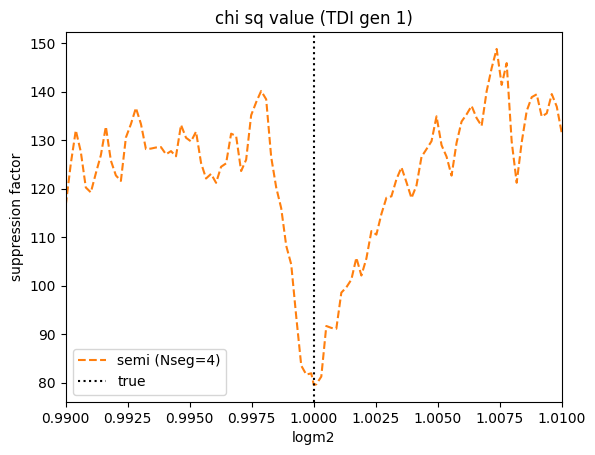

In [29]:
# plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, chi_sq_sc, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
# plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'chi sq value (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
beta_sc

array([0.01234666, 0.01233963, 0.01231933, 0.01232011, 0.01229785,
       0.01230235, 0.01226169, 0.01228095, 0.01226339, 0.01226058,
       0.0122512 , 0.01224049, 0.01223032, 0.01222133, 0.01221124,
       0.01219865, 0.0121902 , 0.0121727 , 0.01216958, 0.01214839,
       0.01214991, 0.01211913, 0.01213009, 0.01210292, 0.01211025,
       0.01208824, 0.01209067, 0.01206552, 0.01207119, 0.01204408,
       0.01205162, 0.01202566, 0.0120319 , 0.01200856, 0.01201203,
       0.01199176, 0.01199208, 0.01197524, 0.01197222, 0.01195896,
       0.01195269, 0.01194153, 0.01193349, 0.01191991, 0.01191412,
       0.01189403, 0.01189467, 0.01186837, 0.01187623, 0.01183946,
       0.01186038, 0.01185685, 0.01182394, 0.01183537, 0.01181061,
       0.0118158 , 0.01177798, 0.011797  , 0.01176246, 0.01177998,
       0.01176647, 0.01175848, 0.0117442 , 0.01173805, 0.01172595,
       0.01171995, 0.01171072, 0.01170088, 0.01169077, 0.01167828,
       0.01167222, 0.01164706, 0.01165127, 0.01162083, 0.01163

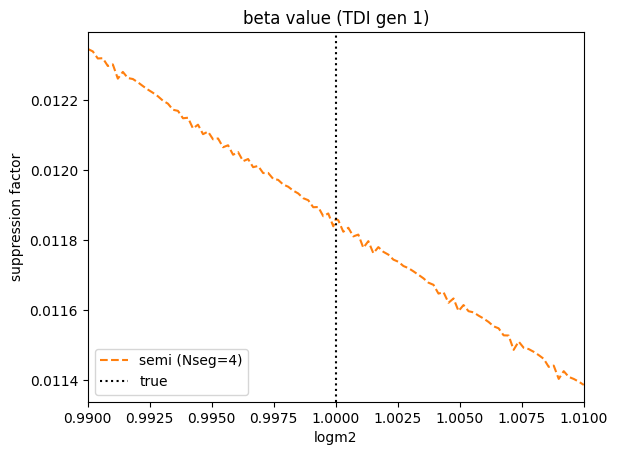

In [31]:
# plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, beta_sc, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
# plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'beta value (TDI gen 1)')
plt.legend(loc='lower left')
# plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

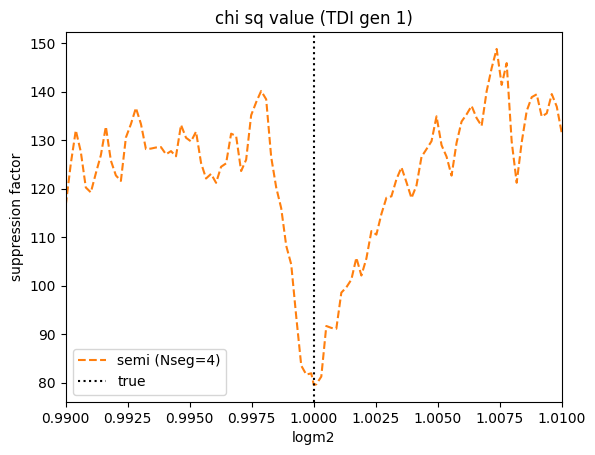

In [32]:
# plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, chi_sq_sc, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
# plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'chi sq value (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

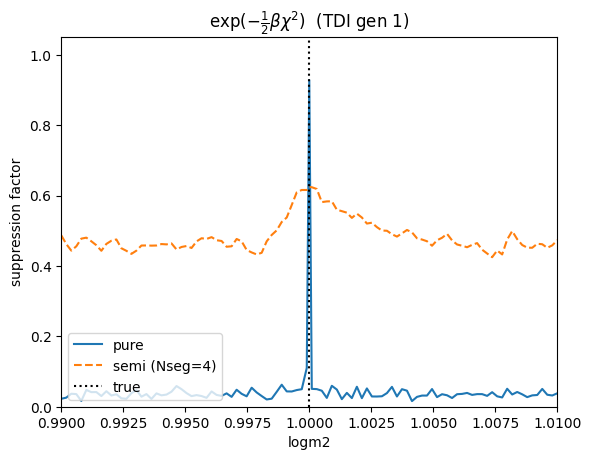

In [33]:
plt.plot(param_range, supp_pure,   label='pure', color='C0')
plt.plot(param_range, suppression, label='semi (Nseg=4)', color='C1', ls='--')
plt.axvline(param_true[param_idx], color='k', ls=':', label='true')
plt.xlim(0.99, 1.01)
plt.ylim(0, 1.05)
plt.xlabel('logm2')
plt.ylabel('suppression factor')
plt.title(r'$\exp(-\frac{1}{2}\beta\chi^2)$  (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
N_seg_list = [2, 4, 6, 12]

selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

# semi suppression for each N_seg; pure once (independent of N_seg)
supp_semi_N = {N: np.zeros(len(param_range)) for N in N_seg_list}
supp_pure   = np.zeros(len(param_range))

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    logm1, logm2, a_i, p0_i, e0_i = p
    theta = [10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]

    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)

    for N in N_seg_list:
        supp_semi_N[N][i] = gwf.chi2_semi(loglike_obj.signal, h, hm_arr, N_seg=N)['suppression']

    supp_pure[i] = chi2_pure(p)['suppression']

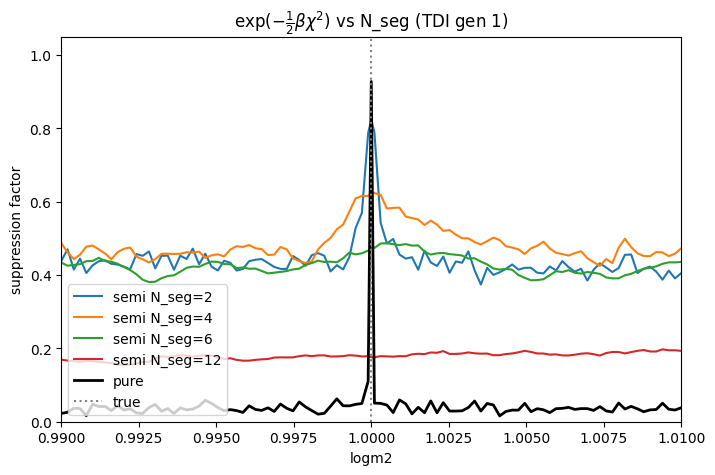

In [35]:
plt.figure(figsize=(8, 5))
for N in N_seg_list:
    plt.plot(param_range, supp_semi_N[N], label=f'semi N_seg={N}')
plt.plot(param_range, supp_pure, 'k', lw=2, label='pure')
plt.axvline(param_true[param_idx], color='gray', ls=':', label='true')
plt.xlim(0.99, 1.01); plt.ylim(0, 1.05)
plt.xlabel('logm2'); plt.ylabel('suppression factor')
plt.title(r'$\exp(-\frac{1}{2}\beta\chi^2)$ vs N_seg (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('suppression_Nseg.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
chisq_semi_N = {N: np.zeros(len(param_range)) for N in N_seg_list}
chisq_pure   = np.zeros(len(param_range))

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    logm1, logm2, a_i, p0_i, e0_i = p
    theta = [10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0]

    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)

    for N in N_seg_list:
        chisq_semi_N[N][i] = gwf.chi2_semi(loglike_obj.signal, h, hm_arr, N_seg=N)['chi_sq']

    chisq_pure[i] = chi2_pure(p)['chi_sq']

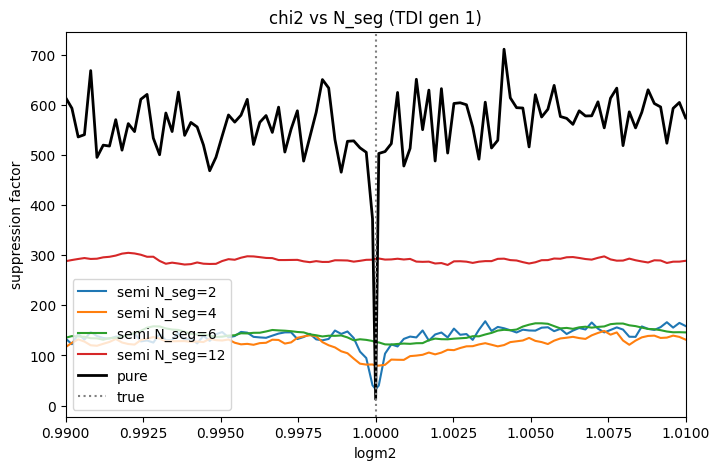

In [37]:
plt.figure(figsize=(8, 5))
for N in N_seg_list:
    plt.plot(param_range, chisq_semi_N[N], label=f'semi N_seg={N}')
plt.plot(param_range, chisq_pure, 'k', lw=2, label='pure')
plt.axvline(param_true[param_idx], color='gray', ls=':', label='true')
plt.xlim(0.99, 1.01)
plt.xlabel('logm2'); plt.ylabel('suppression factor')
plt.title(r'chi2 vs N_seg (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

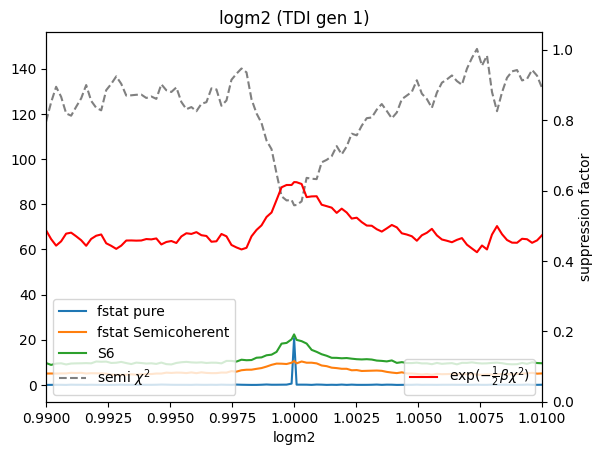

In [38]:
fig, ax = plt.subplots()

# left axis: f-stats (same as before)
ax.plot(param_range, f_stats_pure, label='fstat pure')
ax.plot(param_range, Sf,    label='fstat Semicoherent')
ax.plot(param_range, Sfour, label='S6')
ax.plot(param_range, chi_sq_sc, label=r'semi $\chi^2$', ls='--', color='gray')
ax.set_xlim(0.99, 1.01)
ax.set_title('logm2 (TDI gen 1)')
ax.set_xlabel('logm2')
ax.legend(loc='lower left')

# right axis: exponential suppression factor (0..1)
ax2 = ax.twinx()
ax2.plot(param_range, suppression, color='red',
        label=r'$\exp(-\frac{1}{2}\beta\chi^2)$')
ax2.set_ylabel('suppression factor')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right')

plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
proc1_maxld_pt=np.array([[5.94945358, 0.88479404, 0.67267219, 9.27361124, 0.47424055]])


In [40]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [41]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

In [42]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [43]:
i = 1 #logm2
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [44]:
N_seg = 4
selected = loglike_obj.mode_select if loglike_obj.mode_select else loglike_obj.selected_labels

n_pts     = line_points_logm1.shape[1]
S_line    = np.zeros(n_pts)   # semicoherent S
Sf_line   = np.zeros(n_pts)   # semicoherent f
fpure_line = np.zeros(n_pts)  # pure (coherent) f-stat

for j in range(n_pts):
    pt = line_points_logm1[:, j]                 # 5-dim search point
    logm1, logm2, a_i, p0_i, e0_i = pt

    theta = [
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
    ]

    h = gwf.xp.array(waveform_response(*theta, T=T, dt=dt))
    hm_arr = loglike_obj._generate_selected_waveforms(theta, selected)

    S_line[j]     = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=N_seg))
    Sf_line[j]    = float(gwf.Sf(loglike_obj.signal, h, hm_arr, N_seg=N_seg))
    fpure_line[j] = float(logden_pure(pt))       # pure f-stat, same 5-dim point

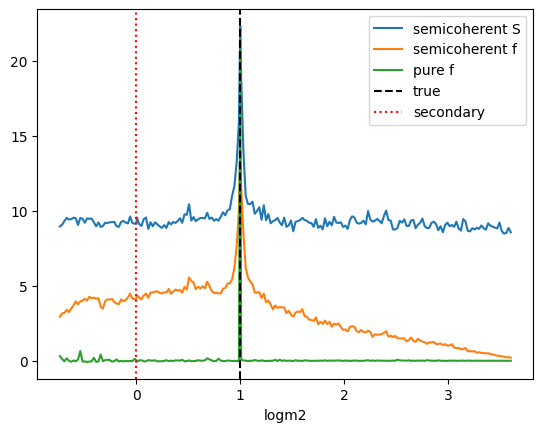

In [45]:
plt.plot(t_values_logm1, S_line,     label='semicoherent S')
plt.plot(t_values_logm1, Sf_line,    label='semicoherent f')
plt.plot(t_values_logm1, fpure_line, label='pure f')
plt.axvline(t_true,      color='k', ls='--', label='true')
plt.axvline(t_secondary, color='r', ls=':',  label='secondary')
plt.xlabel('logm2')
plt.legend()
plt.show()

In [46]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [47]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1, traj_args=[m1, m2, a, e0, xI0])


7.688179003044686

In [48]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1.4, traj_args=[m1, m2, a, e0, xI0])


8.27439325917951